# **Prediksi Polusi Udara**

## **Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, LSTM

## **Load Data**

In [9]:
df = pd.read_csv("../data/raw/ENV_data_2025-06-21_to_2025-07-10.csv", index_col=0, parse_dates=True)

df.drop(columns=["entry_id", "latitude", "longitude", "elevation", "status"], inplace=True)
df = df.rename(columns={
        'field1': 'Temperature',
        'field2': 'Humidity',
        'field3': 'PM2.5',
        'field4': 'PM10',
        'field5': 'CO',
        'field6': 'CO2'
    })

In [14]:
df = df[df.index >= '2025-06-21']
df.isna().sum()

Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

In [27]:
df[(df.index >= '2025-06-29') & (df.index <= '2025-06-30')]

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-29 00:00:23+07:00,24.0,86.7,35.1,53.4,1.23349,406.87848
2025-06-29 00:01:13+07:00,24.0,86.6,35.8,56.9,1.25213,407.08127
2025-06-29 00:03:00+07:00,23.9,86.7,34.9,59.6,1.28370,406.92871
2025-06-29 00:03:53+07:00,23.9,86.7,36.1,59.3,1.23040,406.87848
2025-06-29 00:04:42+07:00,23.9,86.5,33.6,55.2,1.19385,406.75421
...,...,...,...,...,...,...
2025-06-29 23:56:18+07:00,24.9,86.1,30.9,43.3,0.63619,404.28058
2025-06-29 23:57:07+07:00,25.0,85.9,30.0,43.7,0.70290,404.20480
2025-06-29 23:57:57+07:00,25.0,85.9,29.8,41.3,0.65847,404.08905


In [16]:
df_resampled = df.resample('1min').mean().interpolate(method='linear')

In [17]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28372 entries, 2025-06-21 00:00:00+07:00 to 2025-07-10 16:51:00+07:00
Freq: min
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  28372 non-null  float64
 1   Humidity     28372 non-null  float64
 2   PM2.5        28372 non-null  float64
 3   PM10         28372 non-null  float64
 4   CO           28372 non-null  float64
 5   CO2          28372 non-null  float64
dtypes: float64(6)
memory usage: 1.5 MB


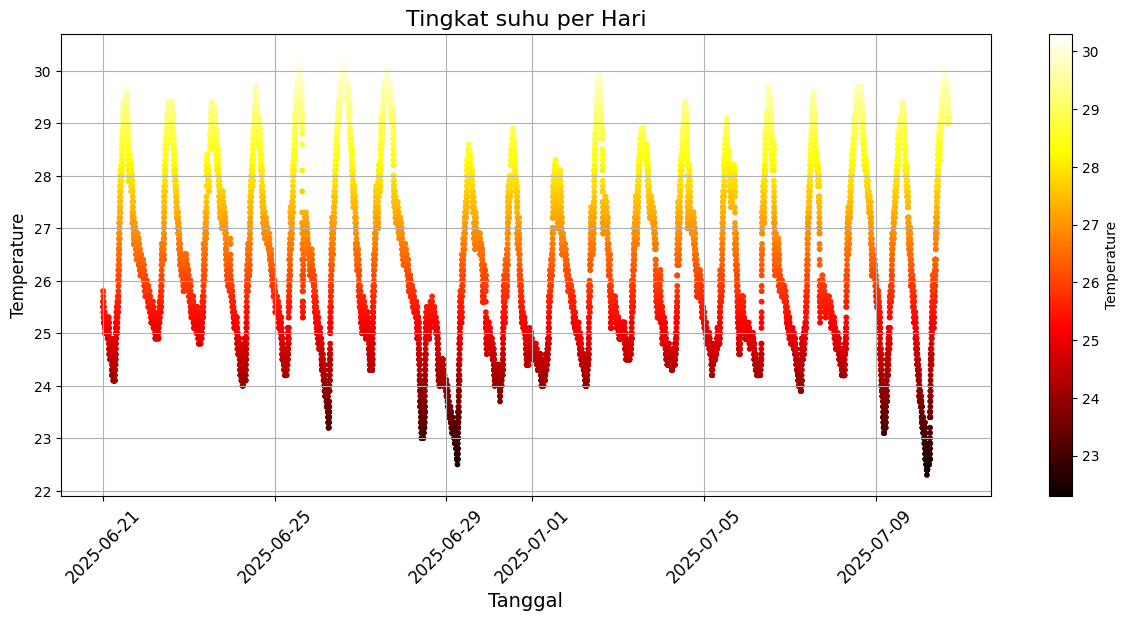

In [24]:
plt.figure(figsize=(15,6))
plt.scatter(df.index, df['Temperature'], c=df['Temperature'], cmap='hot', s=10)
plt.title('Tingkat suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Temperature', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Temperature')
plt.grid(True)

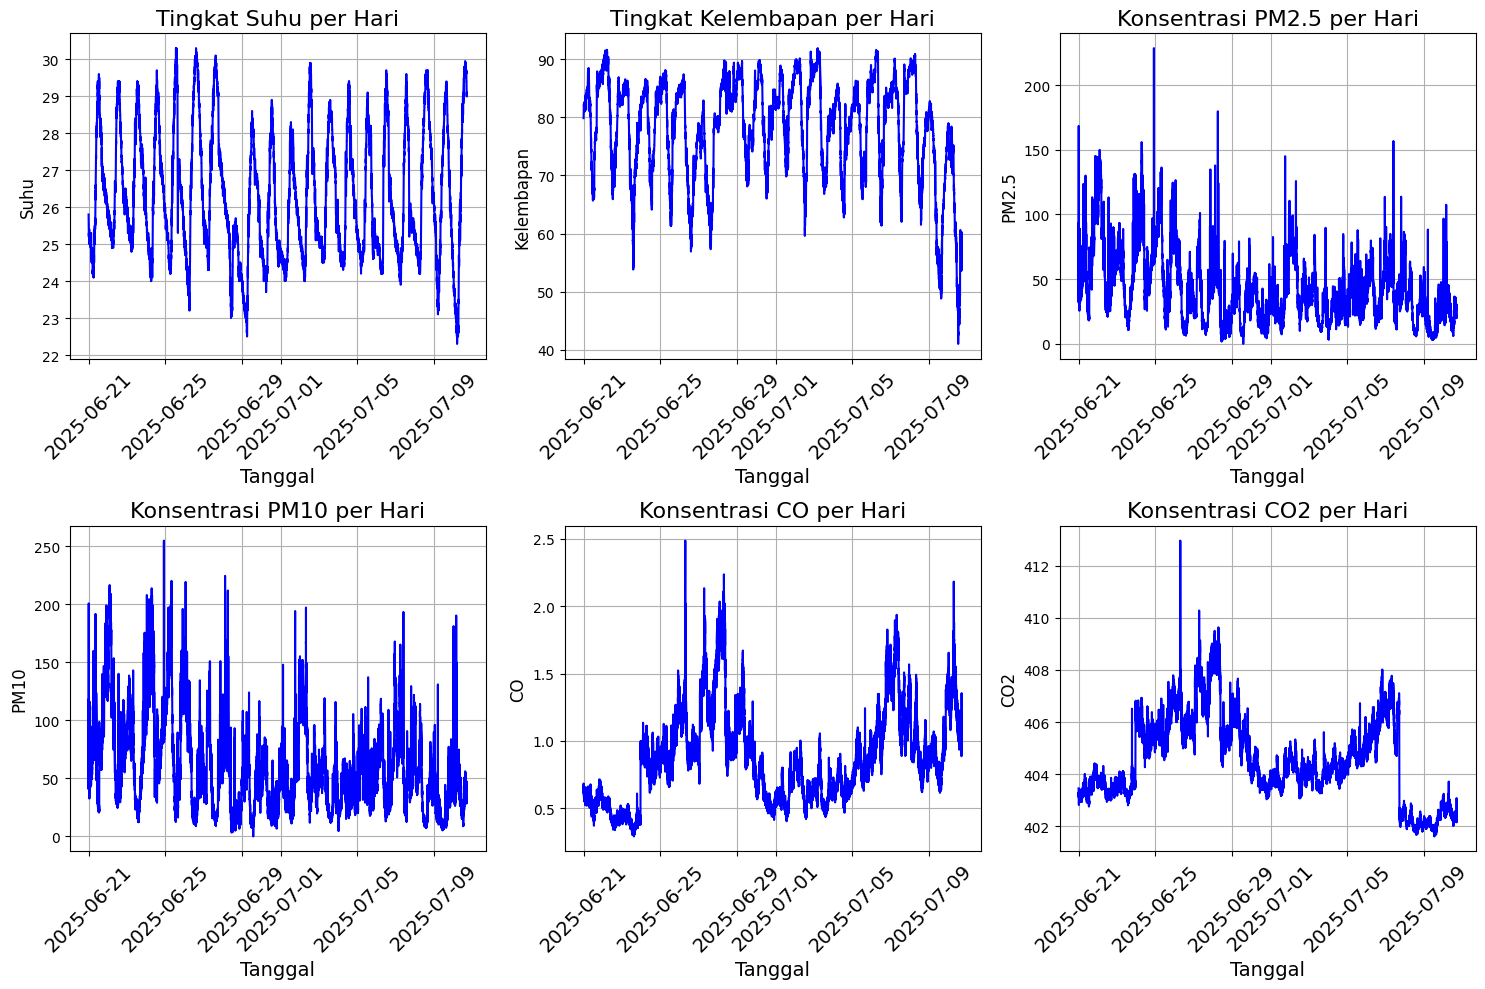

In [18]:
plt.figure(figsize=(15, 10))
plt.subplot(231)
sns.lineplot(data=df_resampled, x='created_at', y='Temperature', color='blue', markers='o')
plt.title('Tingkat Suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Suhu', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(232)
sns.lineplot(data=df_resampled, x='created_at', y='Humidity', color='blue', markers='o')
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Kelembapan', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(233)
sns.lineplot(data=df_resampled, x='created_at', y='PM2.5', color='blue', markers='o')
plt.title('Konsentrasi PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(234)
sns.lineplot(data=df_resampled, x='created_at', y='PM10', color='blue', markers='o')
plt.title('Konsentrasi PM10 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM10', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(235)
sns.lineplot(data=df_resampled, x='created_at', y='CO', color='blue', markers='o')
plt.title('Konsentrasi CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.subplot(236)
sns.lineplot(data=df_resampled, x='created_at', y='CO2', color='blue', markers='o')
plt.title('Konsentrasi CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2', fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

## **Data Splitting dan Window**

In [7]:
# Tentukan proporsi
n = len(df_resampled)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

# Split berdasarkan urutan waktu
train_df = df_resampled.iloc[:train_size]
val_df   = df_resampled.iloc[train_size:train_size + val_size]
test_df  = df_resampled.iloc[train_size + val_size:]

**Scaling**

In [8]:
def scale_dataset_per_feature(df):
    scalers = []
    scaled_data = []

    for col in df.columns:
        scaler = MinMaxScaler()
        scaled_col = scaler.fit_transform(df[[col]])  # tetap bentuk 2D
        scaled_data.append(scaled_col)
        scalers.append(scaler)

    scaled_array = np.hstack(scaled_data)
    return scaled_array, scalers

train_scaled, scalers = scale_dataset_per_feature(train_df)
val_scaled = np.hstack([scalers[i].transform(val_df[[col]]) for i, col in enumerate(val_df.columns)])
test_scaled = np.hstack([scalers[i].transform(test_df[[col]]) for i, col in enumerate(test_df.columns)])


**Window**

In [9]:
tf.random.set_seed(42)

# Membuat fungsi untuk split data input dan target
def split_inputs_and_targets(mulvar_series, ahead=60, target_cols=[2, 3, 4, 5]):
    # input semua timestamp kecuali 10 langkah ke depan
    X = mulvar_series[:, :-ahead, :]

    # output: nilai aktual untuk 60 langkah kedepan
    Y = mulvar_series[:, -ahead:, :]
    Y = tf.gather(Y, target_cols, axis=-1) 
    
    return X, Y

In [10]:
# === Konfigurasi
seq_length = 60   # input 60 menit ke belakang
ahead = 60        # prediksi 60 menit ke depan
target_cols = [2, 3, 4, 5]  # PM2.5, PM10, CO, CO2

# === Dataset Training
ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Validasi
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets)

# === Dataset Testing (jangan di-shuffle)
ahead_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets)

In [11]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename 
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, model_name), # create filepath to save model
    verbose=0, # only output a limited amount of text
    save_best_only=True) # save only the best model to file

## **Model Experiment**

### Model 1: LSTM(4 layer) (Window = 60, horizon = 60)

In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(60, 6)),  # 60 timesteps, 6 fitur
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(60 * 4),                 # 60 langkah output * 4 fitur
    tf.keras.layers.Reshape((60, 4))               # Kembalikan ke shape: (60, 4)
], name="Model_1_LSTM")

In [19]:
optimizer = tf.keras.optimizers.Adam()
model_1.compile(loss="mae", optimizer=optimizer, metrics=["mae"])

In [20]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_mse', patience=10, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model_lstm_trial.h5", save_best_only=True, monitor="val_mse")

In [21]:
model_1.summary()

Model: "Model_1_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           69120     
                                                                 
 lstm_1 (LSTM)               (None, 60, 128)           131584    
                                                                 
 lstm_2 (LSTM)               (None, 60, 256)           394240    
                                                                 
 lstm_3 (LSTM)               (None, 128)               197120    
                                                                 
 dense (Dense)               (None, 240)               30960     
                                                                 
 reshape (Reshape)           (None, 60, 4)             0         
                                                                 
Total params: 823,024
Trainable params: 823,024
Non-tr

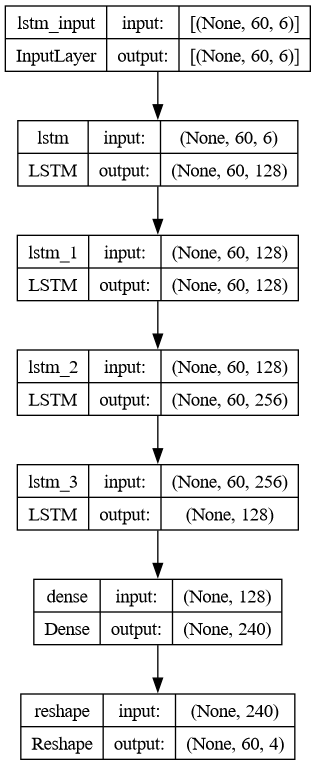

In [22]:
tf.keras.utils.plot_model(model_1, show_shapes=True)

In [23]:
with tf.device('/GPU:0'):
    history = model_1.fit(ahead_train_ds, epochs=100, validation_data=ahead_valid_ds, callbacks=[create_model_checkpoint(model_name=model_1.name)])

Epoch 1/100
91/91 [==============================] - ETA: 0s - loss: 0.1213 - mae: 0.1213

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


91/91 [==============================] - 21s 132ms/step - loss: 0.1213 - mae: 0.1213 - val_loss: 0.0793 - val_mae: 0.0793
Epoch 2/100
89/91 [============================>.] - ETA: 0s - loss: 0.0783 - mae: 0.0783

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


91/91 [==============================] - 11s 117ms/step - loss: 0.0783 - mae: 0.0783 - val_loss: 0.0679 - val_mae: 0.0679
Epoch 3/100
89/91 [============================>.] - ETA: 0s - loss: 0.0719 - mae: 0.0719

INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


INFO:tensorflow:Assets written to: model_experiments\Model_1_LSTM\assets


91/91 [==============================] - 10s 115ms/step - loss: 0.0719 - mae: 0.0719 - val_loss: 0.0679 - val_mae: 0.0679
Epoch 4/100
91/91 [==============================] - 2s 26ms/step - loss: 0.0675 - mae: 0.0675 - val_loss: 0.0907 - val_mae: 0.0907
Epoch 5/100
91/91 [==============================] - 2s 24ms/step - loss: 0.0671 - mae: 0.0671 - val_loss: 0.0746 - val_mae: 0.0746
Epoch 6/100
91/91 [==============================] - 2s 24ms/step - loss: 0.0620 - mae: 0.0620 - val_loss: 0.0849 - val_mae: 0.0849
Epoch 7/100
91/91 [==============================] - 2s 25ms/step - loss: 0.0559 - mae: 0.0559 - val_loss: 0.1221 - val_mae: 0.1221
Epoch 8/100
91/91 [==============================] - 2s 25ms/step - loss: 0.0554 - mae: 0.0554 - val_loss: 0.0885 - val_mae: 0.0885
Epoch 9/100
91/91 [==============================] - 2s 25ms/step - loss: 0.0516 - mae: 0.0516 - val_loss: 0.1013 - val_mae: 0.1013
Epoch 10/100
91/91 [==============================] - 2s 25ms/step - loss: 0.0480 - ma

In [24]:
model_1.evaluate(ahead_test_ds)

17/17 [==============================] - 0s 17ms/step - loss: 0.5199 - mae: 0.5199


[0.5198764801025391, 0.5198765397071838]

In [26]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/Model_1_LSTM")
model_1.evaluate(ahead_test_ds)

17/17 [==============================] - 1s 19ms/step - loss: 0.4870 - mae: 0.4870


[0.4870259463787079, 0.4870259165763855]

In [31]:
def plot_seq2seq_vs_actual(y_true_all, y_pred_all, scalers, target_names, target_indices):
    """
    Visualisasi hasil prediksi vs aktual untuk setiap fitur target, 
    dengan hanya mengambil 1 titik prediksi per window (misalnya prediksi menit ke-60).
    
    Args:
        y_true_all: shape (batch, 60, n_target) - ground truth
        y_pred_all: shape (batch, 60, n_target) - model output
        scalers: list of fitted scalers per fitur dari fungsi scale_dataset_per_feature()
        target_names: list nama target (misalnya ['PM2.5', 'PM10', 'CO', 'CO2'])
        target_indices: index kolom target pada scaler (misal [2, 3, 4, 5])
    """

    # Invers transform semua fitur target
    y_true_inv_all = y_true_all.copy()
    y_pred_inv_all = y_pred_all.copy()

    for i, idx in enumerate(target_indices):
        for j in range(y_true_all.shape[0]):
            y_true_inv_all[j, :, i] = scalers[idx].inverse_transform(
                y_true_all[j, :, i].reshape(-1, 1)
            ).reshape(-1)

            y_pred_inv_all[j, :, i] = scalers[idx].inverse_transform(
                y_pred_all[j, :, i].reshape(-1, 1)
            ).reshape(-1)

    # Ambil hanya 1 titik prediksi terakhir dari setiap window
    for i, name in enumerate(target_names):
        y_true_last = y_true_inv_all[:, -1, i]  # timestep ke-60
        y_pred_last = y_pred_inv_all[:, -1, i]

        # timeline offset: jumlah langkah awal yang di-skip oleh window
        offset = seq_length + ahead - 1
        timesteps = np.arange(offset, offset + len(y_true_last))

        plt.figure(figsize=(14, 5))
        plt.plot(timesteps, y_true_last, label=f"Aktual {name}")
        plt.plot(timesteps, y_pred_last, label=f"Prediksi {name}")
        plt.title(f"Prediksi vs Aktual - {name} (titik terakhir tiap window)")
        plt.xlabel("Menit ke-")
        plt.ylabel(name)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


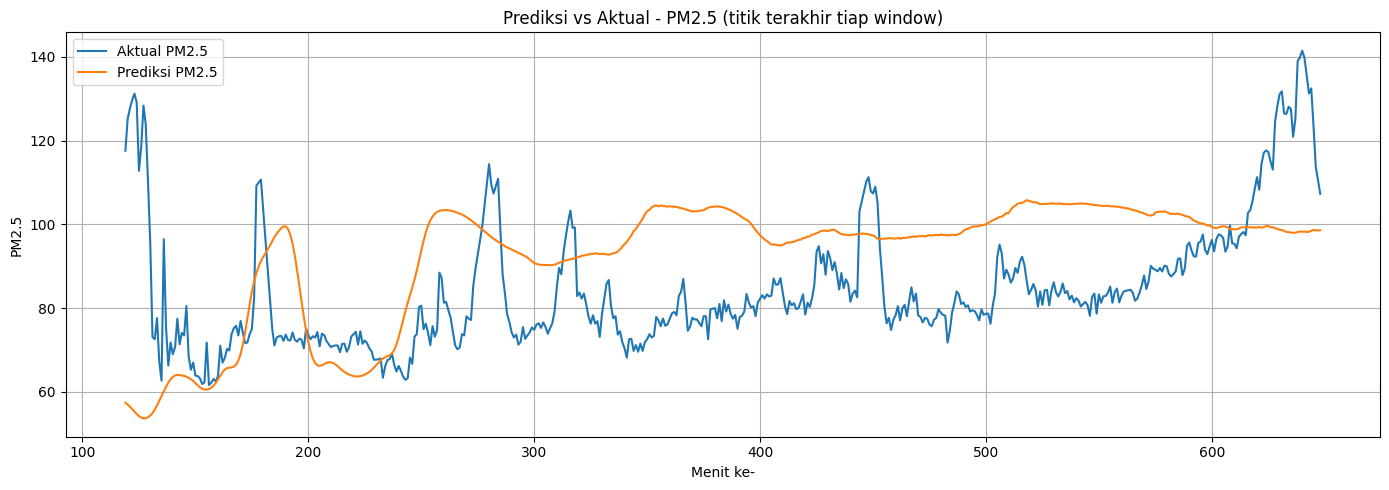

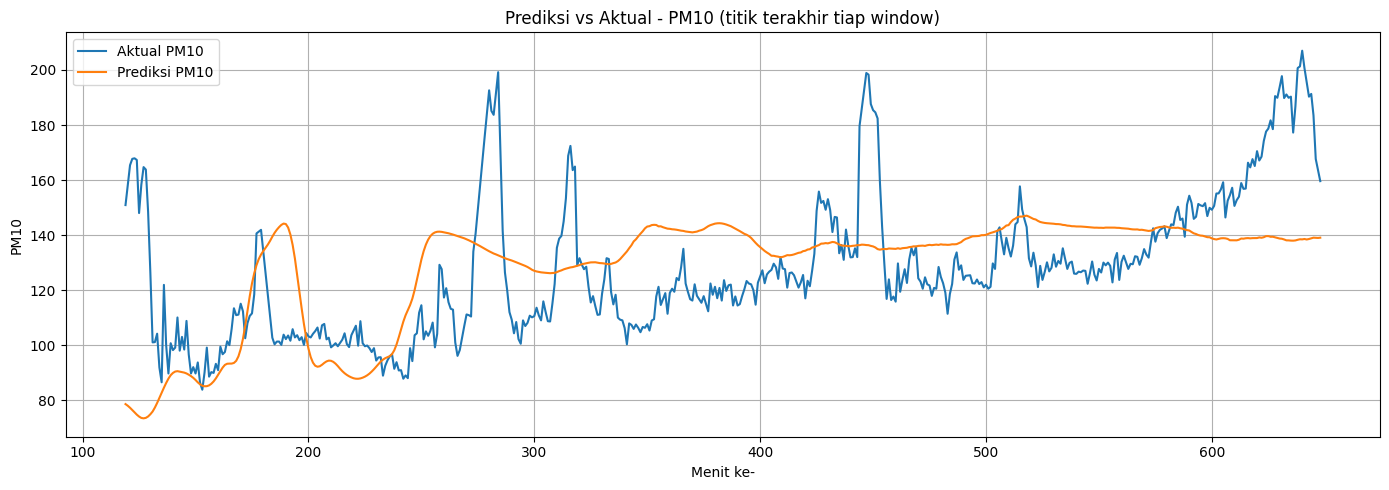

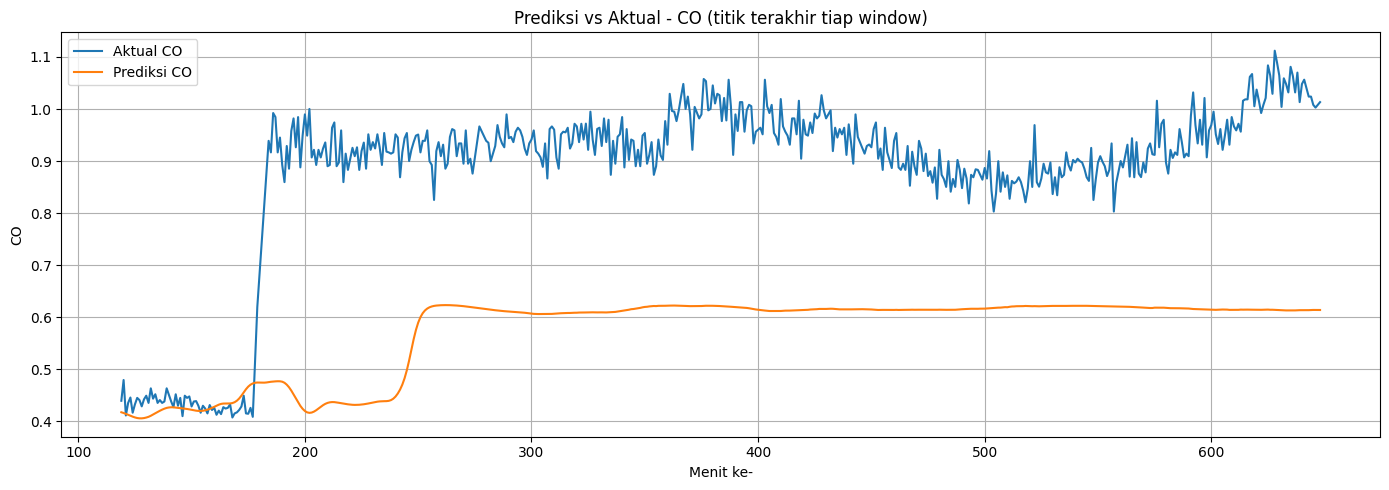

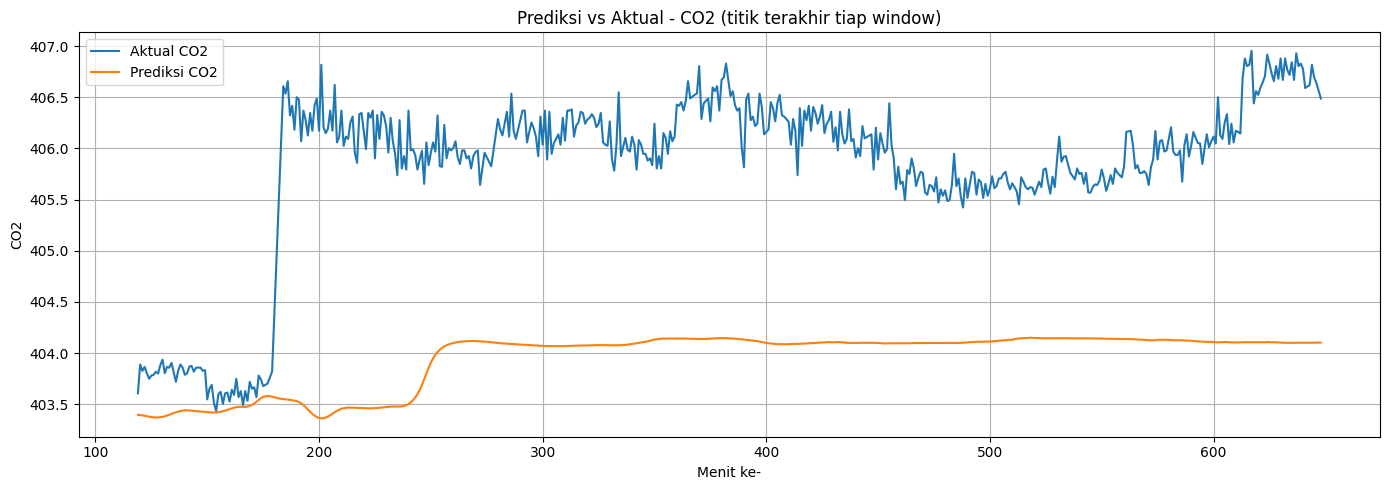

In [32]:
plot_seq2seq_vs_actual(
    y_true_all=y_true_all,
    y_pred_all=y_pred_all,
    scalers=scalers,
    target_names=["PM2.5", "PM10", "CO", "CO2"],
    target_indices=[2, 3, 4, 5]
)

**Test Prediksi hanya untuk PM2.5**

In [ ]:
def split_inputs_and_targets_pm25_multistep(series, ahead=60, target_col=2):
    X = series[:, :-ahead, :]                    # (batch, 120, 6)
    Y = series[:, -ahead:, target_col]           # (batch, 60)
    Y = tf.expand_dims(Y, -1)                    # (batch, 60, 1)
    return X, Y


In [ ]:
seq_length = 120
ahead = 60

pm25_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=val_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

pm25_test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=seq_length + ahead,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
).map(split_inputs_and_targets_pm25_multistep)

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

pm25_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(120, train_scaled.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(256),
    tf.keras.layers.Dense(60),
    tf.keras.layers.Reshape((60, 1))
])

In [ ]:
pm25_model.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

with tf.device('/GPU:0'):
    history = pm25_model.fit(
        pm25_train_ds,
        validation_data=pm25_valid_ds,
        epochs=30,
        callbacks=[early_stopping]
    )


Epoch 1/30
89/89 [==============================] - 5s 32ms/step - loss: 0.0201 - mae: 0.1006 - val_loss: 0.0039 - val_mae: 0.0498
Epoch 2/30
89/89 [==============================] - 2s 22ms/step - loss: 0.0109 - mae: 0.0791 - val_loss: 0.0027 - val_mae: 0.0399
Epoch 3/30
89/89 [==============================] - 2s 22ms/step - loss: 0.0101 - mae: 0.0764 - val_loss: 0.0048 - val_mae: 0.0566
Epoch 4/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0102 - mae: 0.0769 - val_loss: 0.0030 - val_mae: 0.0424
Epoch 5/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0093 - mae: 0.0734 - val_loss: 0.0091 - val_mae: 0.0819
Epoch 6/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0094 - mae: 0.0737 - val_loss: 0.0059 - val_mae: 0.0612
Epoch 7/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0100 - mae: 0.0762 - val_loss: 0.0043 - val_mae: 0.0549
Epoch 8/30
89/89 [==============================] - 2s 21ms/step - loss: 0.0094 - m

In [ ]:
pm25_model.evaluate(pm25_test_ds)

15/15 [==============================] - 0s 9ms/step - loss: 0.0112 - mae: 0.0806


[0.011196167208254337, 0.08056917041540146]

1/1 [==============================] - 0s 402ms/step


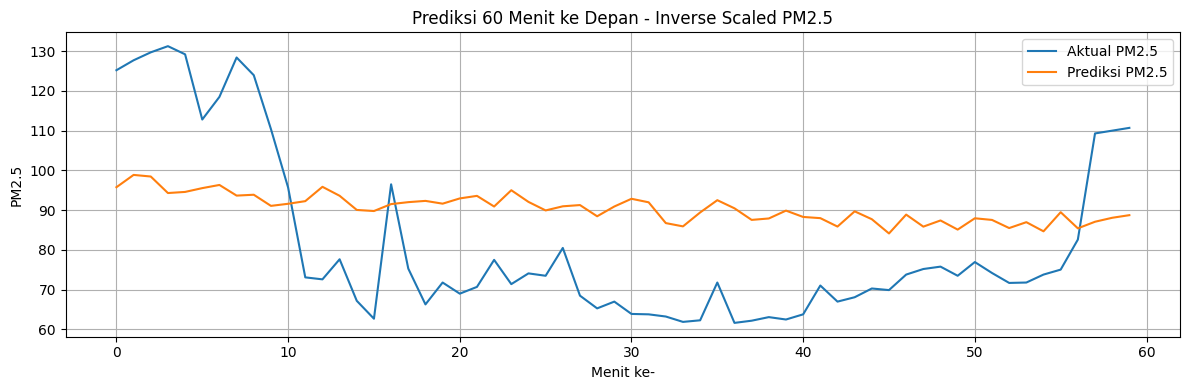

In [ ]:
for x_batch, y_true in pm25_test_ds.take(1):
    y_pred = pm25_model.predict(x_batch)

    # Ambil 1 sample dari batch
    y_true_sample = y_true[0].numpy().reshape(-1, 1)
    y_pred_sample = y_pred[0].reshape(-1, 1)

    # Inverse scaling
    y_true_inv = scalers[2].inverse_transform(y_true_sample).flatten()
    y_pred_inv = scalers[2].inverse_transform(y_pred_sample).flatten()

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(y_true_inv, label='Aktual PM2.5')
    plt.plot(y_pred_inv, label='Prediksi PM2.5')
    plt.title('Prediksi 60 Menit ke Depan - Inverse Scaled PM2.5')
    plt.xlabel('Menit ke-')
    plt.ylabel('PM2.5')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
x_batch.shape

TensorShape([32, 120, 6])

In [ ]:
pm25_model.input_shape

(None, 120, 6)

In [ ]:
for x_batch, y_true in pm25_test_ds.take(1):
    print(x_batch.shape)  # Harusnya: (32, 60, 6)
    print(y_true.shape)   # Harusnya: (32, 1, 1)

(32, 120, 6)
(32, 60, 1)


In [ ]:
y_pred = pm25_model.predict(x_batch)


1/1 [==============================] - 0s 31ms/step


**Trial Seq2seq**

In [ ]:
def to_seq2seq_dataset(series, seq_length=60, ahead=60, target_cols=[2, 3, 4, 5],
                       batch_size=32, shuffle=False, seed=None):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=series,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size,
        seed=seed
    ).map(lambda S: (
        S[:, :seq_length, :],
        tf.gather(S[:, seq_length:, :], target_cols, axis=-1)
    ))
    return ds

In [ ]:
seq2seq_train = to_seq2seq_dataset(train_scaled, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(val_scaled)
seq2seq_test = to_seq2seq_dataset(test_scaled)

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
tf.keras.backend.clear_session()
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=[None, 6]),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(60 * 4),                 # 60 langkah output * 4 fitur
    tf.keras.layers.Reshape((60, 4))               # Kembalikan ke shape: (60, 4)
])

In [ ]:
seq2seq_model.compile(loss="mse", optimizer=optimizer, metrics=["mse"])

In [ ]:
with tf.device('/GPU:0'):
    history = seq2seq_model.fit(seq2seq_train, epochs=30, validation_data=seq2seq_valid, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/30
91/91 [==============================] - 5s 39ms/step - loss: 0.1841 - mse: 0.1841 - val_loss: 0.0311 - val_mse: 0.0311
Epoch 2/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0220 - mse: 0.0220 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 3/30
91/91 [==============================] - 3s 34ms/step - loss: 0.0149 - mse: 0.0149 - val_loss: 0.0232 - val_mse: 0.0232
Epoch 4/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0144 - mse: 0.0144 - val_loss: 0.0258 - val_mse: 0.0258
Epoch 5/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0224 - val_mse: 0.0224
Epoch 6/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0139 - mse: 0.0139 - val_loss: 0.0234 - val_mse: 0.0234
Epoch 7/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0134 - mse: 0.0134 - val_loss: 0.0196 - val_mse: 0.0196
Epoch 8/30
91/91 [==============================] - 3s 35ms/step - loss: 0.0134 - m

In [ ]:
seq2seq_model.evaluate(seq2seq_test)

17/17 [==============================] - 0s 9ms/step - loss: 0.5352 - mse: 0.5352


[0.5351564288139343, 0.5351563692092896]

1/1 [==============================] - 0s 306ms/step


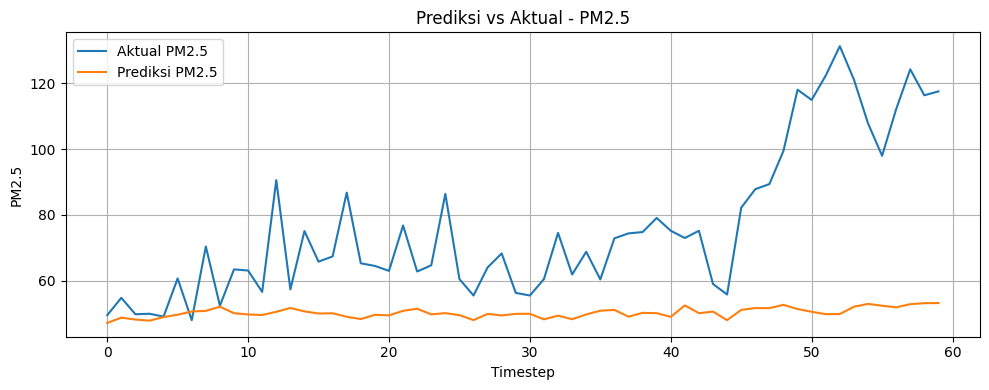

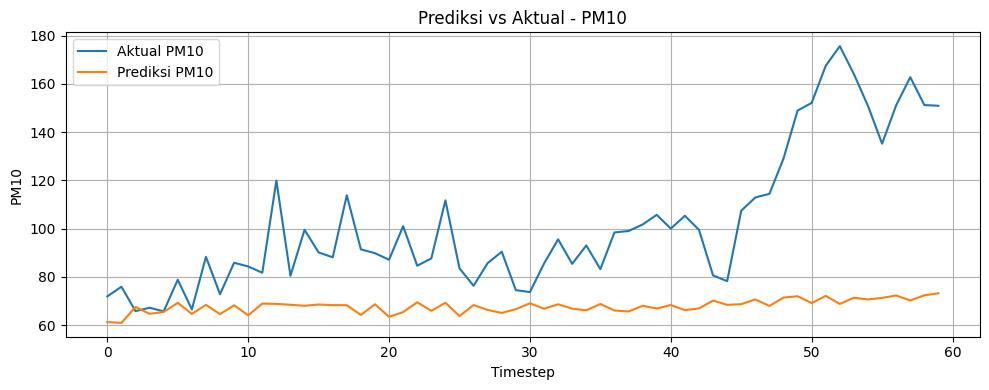

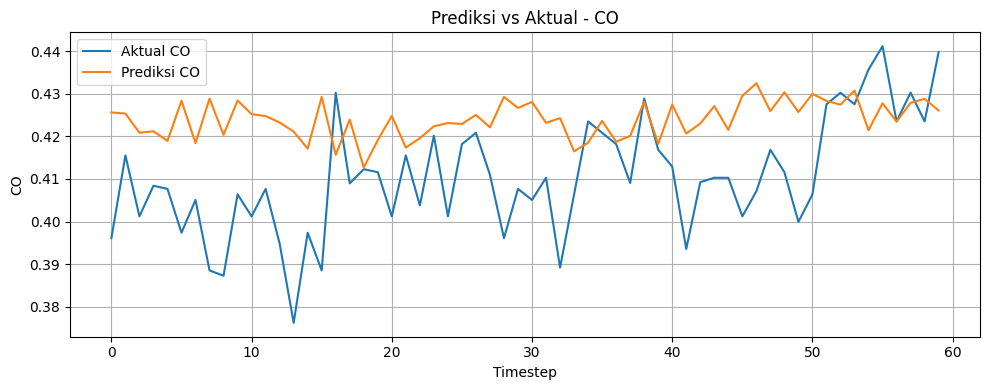

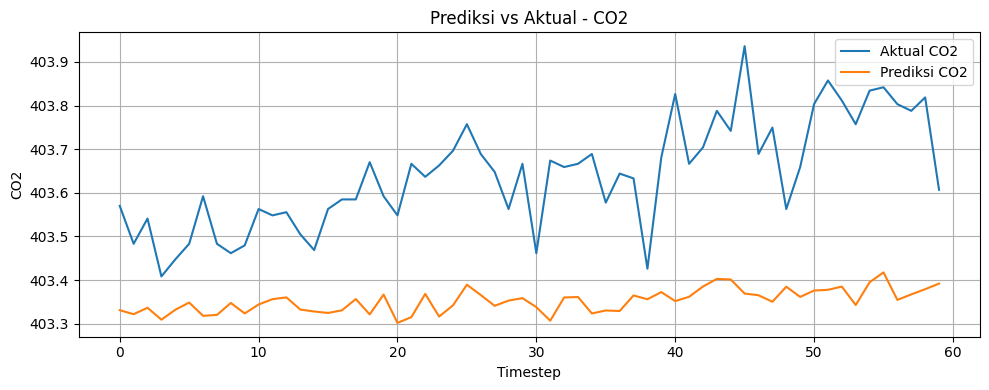

In [ ]:
# Ambil 1 batch dari test set
for X_batch, Y_true in seq2seq_test.take(1):
    Y_pred = seq2seq_model.predict(X_batch)

    # Inverse scaling per fitur
    Y_true_inv = Y_true.numpy().copy()
    Y_pred_inv = Y_pred.copy()

    # target_cols = [2, 3, 4, 5]  # urutan target
    fitur_label = ['PM2.5', 'PM10', 'CO', 'CO2']

    for i, idx in enumerate([2, 3, 4, 5]):
        # Inverse scale untuk fitur target
        scaler = scalers[idx]
        # Bentuk flatten, inverse, lalu reshape ke shape semula
        true_flat = Y_true_inv[:, :, i].reshape(-1, 1)
        pred_flat = Y_pred_inv[:, :, i].reshape(-1, 1)

        true_inv = scaler.inverse_transform(true_flat).reshape(Y_true_inv[:, :, i].shape)
        pred_inv = scaler.inverse_transform(pred_flat).reshape(Y_pred_inv[:, :, i].shape)

        # Visualisasi untuk batch pertama dan fitur ke-i
        plt.figure(figsize=(10, 4))
        plt.plot(true_inv[0], label=f"Aktual {fitur_label[i]}")
        plt.plot(pred_inv[0], label=f"Prediksi {fitur_label[i]}")
        plt.title(f"Prediksi vs Aktual - {fitur_label[i]}")
        plt.xlabel("Timestep")
        plt.ylabel(fitur_label[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


**Dengan Encoder**

In [ ]:
def make_seq2seq_dataset(data, seq_length=60, ahead=60, target_cols=[2,3,4,5],
                         batch_size=32, shuffle=False, seed=None):
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=seq_length + ahead,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size,
        seed=seed
    )

    def map_fn(S):
        encoder_in = S[:, :seq_length, :]
        target_seq = tf.gather(S[:, seq_length:, :], target_cols, axis=-1)
        # decoder input = target sequence geser 1 langkah + padding di depan
        dec_in = tf.pad(target_seq[:, :-1, :], [[0,0],[1,0],[0,0]])
        return (encoder_in, dec_in), target_seq

    return ds.map(map_fn)


In [ ]:
seq2seq_train_enc = make_seq2seq_dataset(train_scaled)
seq2seq_valid_enc = make_seq2seq_dataset(val_scaled)
seq2seq_test_enc  = make_seq2seq_dataset(test_scaled)


In [ ]:
tf.keras.backend.clear_session()

# Encoder-decoder model build di sini

# Encoder
encoder_inputs = Input(shape=(60, 6))  # 60 langkah, 6 fitur input
encoder_lstm = LSTM(128, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# Decoder
decoder_inputs = Input(shape=(60, 4))  # decoder input (output sebelumnya)
decoder_lstm = LSTM(128, return_sequences=True)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=[state_h, state_c])
decoder_dense = Dense(4)  # output 4 fitur per step
decoder_outputs = decoder_dense(decoder_outputs)

# Model
seq2seq_model_enc = Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [ ]:
seq2seq_model_enc.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 60, 6)]      0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 60, 4)]      0           []                               
                                                                                                  
 lstm (LSTM)                    [(None, 128),        69120       ['input_1[0][0]']                
                                 (None, 128),                                                     
                                 (None, 128)]                                                     
                                                                                              

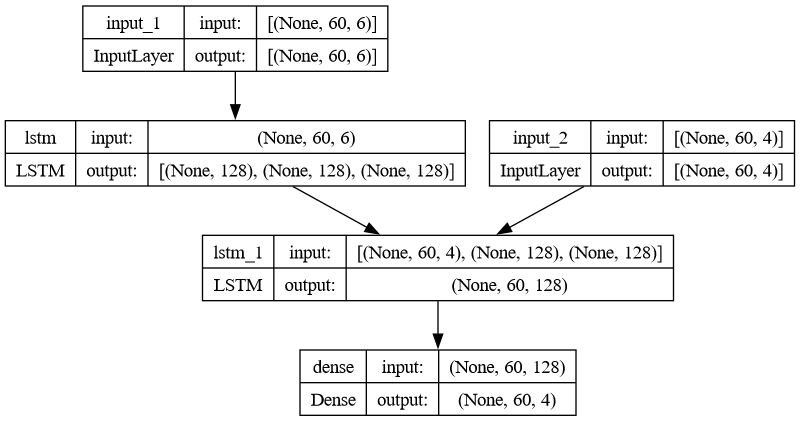

In [ ]:
tf.keras.utils.plot_model(seq2seq_model_enc, show_shapes=True)

In [ ]:
seq2seq_model_enc.compile(optimizer="adam", loss="mse", metrics=["mse"])

In [ ]:
history = seq2seq_model_enc.fit(
    seq2seq_train_enc,
    epochs=30,
    validation_data=seq2seq_valid_enc,
    callbacks=[early_stopping_cb, checkpoint_cb]
)


Epoch 1/30
91/91 [==============================] - 4s 26ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0133 - val_mse: 0.0133
Epoch 2/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0106 - mse: 0.0106 - val_loss: 0.0110 - val_mse: 0.0110
Epoch 3/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0093 - mse: 0.0093 - val_loss: 0.0086 - val_mse: 0.0086
Epoch 4/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 5/30
91/91 [==============================] - 1s 15ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 6/30
91/91 [==============================] - 1s 16ms/step - loss: 0.0052 - mse: 0.0052 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 7/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0045 - mse: 0.0045 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 8/30
91/91 [==============================] - 1s 14ms/step - loss: 0.0042 - m

1/1 [==============================] - 0s 440ms/step


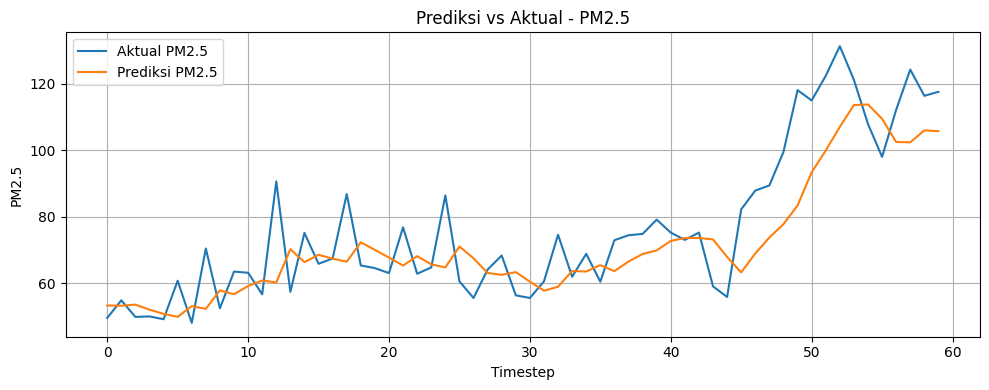

RMSE PM2.5: 12.583


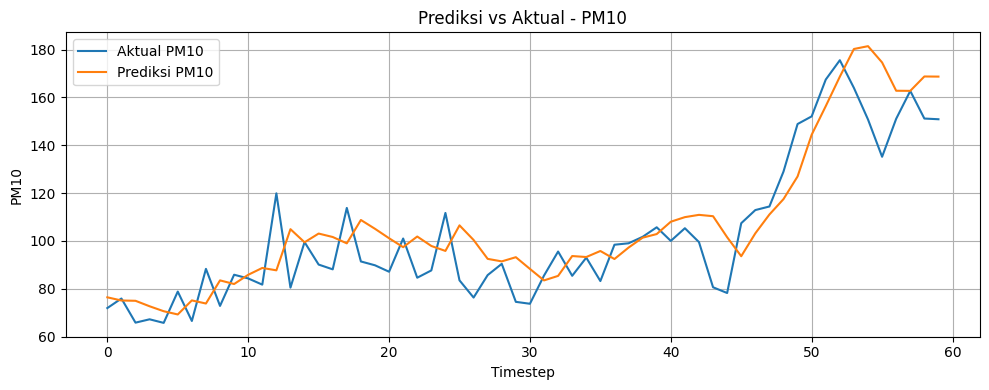

RMSE PM10: 14.568


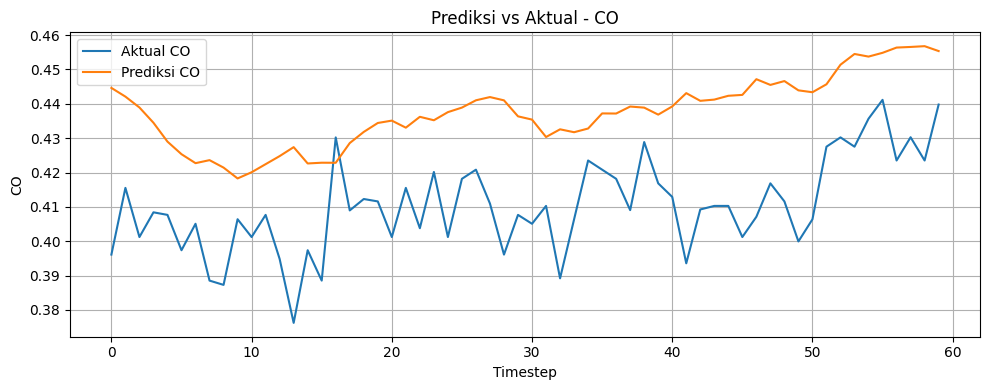

RMSE CO: 0.029


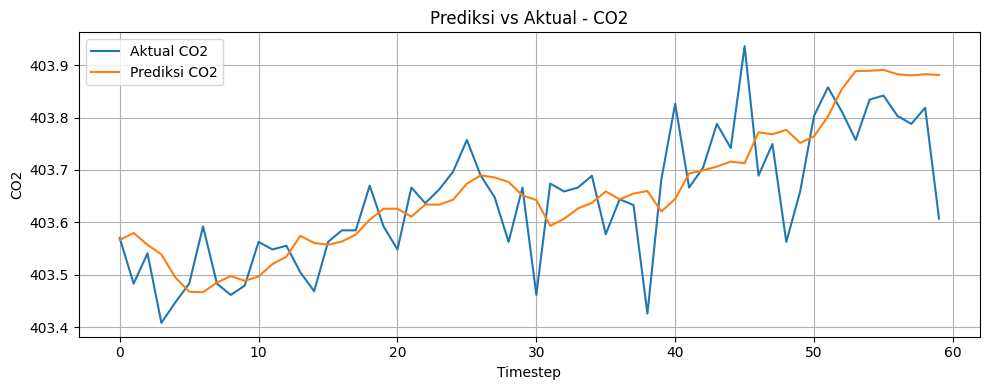

RMSE CO2: 0.091


In [ ]:
from sklearn.metrics import mean_squared_error

for (encoder_in, decoder_in), Y_true in seq2seq_test_enc.take(1):
    Y_pred = seq2seq_model_enc.predict([encoder_in, decoder_in])

    fitur_label = ['PM2.5', 'PM10', 'CO', 'CO2']
    for i, idx in enumerate([2, 3, 4, 5]):
        scaler = scalers[idx]

        true_flat = Y_true[:, :, i].numpy().reshape(-1, 1)
        pred_flat = Y_pred[:, :, i].reshape(-1, 1)

        true_inv = scaler.inverse_transform(true_flat).reshape(Y_true[:, :, i].shape)
        pred_inv = scaler.inverse_transform(pred_flat).reshape(Y_pred[:, :, i].shape)

        # Plot
        plt.figure(figsize=(10,4))
        plt.plot(true_inv[0], label=f"Aktual {fitur_label[i]}")
        plt.plot(pred_inv[0], label=f"Prediksi {fitur_label[i]}")
        plt.title(f"Prediksi vs Aktual - {fitur_label[i]}")
        plt.xlabel("Timestep")
        plt.ylabel(fitur_label[i])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # RMSE
        rmse = np.sqrt(mean_squared_error(true_inv[0], pred_inv[0]))
        print(f"RMSE {fitur_label[i]}: {rmse:.3f}")
